# Phase 4a — Modeling: Effectiveness Classification (Model 1)

**Input:** `benefitsReview` TF-IDF features  
**Target:** `effectiveness` — compared under **5-class** (original) and **3-class** (High / Moderate / Low) schemes  
**Algorithms:** Logistic Regression and Linear SVM (LinearSVC), plus a majority-class baseline

## Model Choice Rationale
- **Logistic Regression** — interpretable baseline; handles high-dimensional sparse TF-IDF well; coefficients show which words drive each class
- **Linear SVM (LinearSVC)** — strong on text classification with TF-IDF; finds max-margin boundaries in high-dimensional space
- **`class_weight='balanced'`** — counters the skew toward Highly/Considerably Effective
- **3 vs 5 class comparison** — quantifies the trade-off between label granularity and predictive reliability

### Load Prepared Data

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.max_open_warning'] = 50
import scipy.sparse as sp
import pandas as pd
import numpy as np
import pickle
from pathlib import Path

X_train = sp.load_npz('../data/processed/X_train_tfidf.npz')
X_test = sp.load_npz('../data/processed/X_test_tfidf.npz')

y_train_5 = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test_5 = pd.read_csv('../data/processed/y_test.csv').squeeze()
y_train_3 = pd.read_csv('../data/processed/y_train_3class.csv').squeeze()
y_test_3 = pd.read_csv('../data/processed/y_test_3class.csv').squeeze()

with open('../data/processed/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_vectorizer = pickle.load(f)

print('TF-IDF train:', X_train.shape, '| test:', X_test.shape)
print('5-class labels:', y_train_5.nunique(), 'classes')
print('3-class labels:', y_train_3.nunique(), 'classes')
print('\n5-class train:\n', y_train_5.value_counts())
print('\n3-class train:\n', y_train_3.value_counts())

TF-IDF train: (3085, 3000) | test: (1030, 3000)
5-class labels: 5 classes
3-class labels: 3 classes

5-class train:
 effectiveness
Highly Effective          1327
Considerably Effective     927
Moderately Effective       414
Ineffective                235
Marginally Effective       182
Name: count, dtype: int64

3-class train:
 effectiveness
High        2254
Low          417
Moderate     414
Name: count, dtype: int64


### Training & Evaluation Helpers

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

Path('../visuals').mkdir(parents=True, exist_ok=True)
Path('../data/processed').mkdir(parents=True, exist_ok=True)

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_te, y_pred),
        'macro_precision': precision_score(y_te, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_te, y_pred, average='macro', zero_division=0),
        'macro_f1': f1_score(y_te, y_pred, average='macro', zero_division=0),
    }
    print('=' * 55)
    print(f'{name} — RESULTS')
    print('=' * 55)
    for k in ['accuracy', 'macro_precision', 'macro_recall', 'macro_f1']:
        print(f"{k}: {metrics[k]:.4f}")
    print('\nClassification Report:\n')
    print(classification_report(y_te, y_pred, zero_division=0))
    return model, y_pred, metrics

def plot_confusion(ax, y_true, y_pred, title, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

### 5-Class Models

In [3]:
labels_5 = sorted(y_train_5.unique())
results = []

log_reg_5 = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg_5, y_pred_lr_5, m = evaluate_model(
    'LR (5-class)', log_reg_5, X_train, y_train_5, X_test, y_test_5)
m['scheme'] = '5-class'
results.append(m)

svm_5 = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)
svm_5, y_pred_svm_5, m = evaluate_model(
    'SVM (5-class)', svm_5, X_train, y_train_5, X_test, y_test_5)
m['scheme'] = '5-class'
results.append(m)

dummy_5 = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_5, y_pred_dummy_5, m = evaluate_model(
    'Baseline majority (5-class)', dummy_5, X_train, y_train_5, X_test, y_test_5)
m['scheme'] = '5-class'
results.append(m)

LR (5-class) — RESULTS
accuracy: 0.4718
macro_precision: 0.4201
macro_recall: 0.4404
macro_f1: 0.4288

Classification Report:

                        precision    recall  f1-score   support

Considerably Effective       0.44      0.41      0.42       310
      Highly Effective       0.61      0.58      0.59       411
           Ineffective       0.49      0.59      0.53        78
  Marginally Effective       0.25      0.27      0.26        74
  Moderately Effective       0.32      0.36      0.34       157

              accuracy                           0.47      1030
             macro avg       0.42      0.44      0.43      1030
          weighted avg       0.48      0.47      0.47      1030

SVM (5-class) — RESULTS
accuracy: 0.4553
macro_precision: 0.3953
macro_recall: 0.4007
macro_f1: 0.3969

Classification Report:

                        precision    recall  f1-score   support

Considerably Effective       0.40      0.36      0.38       310
      Highly Effective       0.56    

### 3-Class Models

In [4]:
labels_3 = ['High', 'Moderate', 'Low']

log_reg_3 = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg_3, y_pred_lr_3, m = evaluate_model(
    'LR (3-class)', log_reg_3, X_train, y_train_3, X_test, y_test_3)
m['scheme'] = '3-class'
results.append(m)

svm_3 = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)
svm_3, y_pred_svm_3, m = evaluate_model(
    'SVM (3-class)', svm_3, X_train, y_train_3, X_test, y_test_3)
m['scheme'] = '3-class'
results.append(m)

dummy_3 = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_3, y_pred_dummy_3, m = evaluate_model(
    'Baseline majority (3-class)', dummy_3, X_train, y_train_3, X_test, y_test_3)
m['scheme'] = '3-class'
results.append(m)

LR (3-class) — RESULTS
accuracy: 0.6777
macro_precision: 0.5555
macro_recall: 0.5800
macro_f1: 0.5649

Classification Report:

              precision    recall  f1-score   support

        High       0.83      0.76      0.79       721
         Low       0.55      0.62      0.58       152
    Moderate       0.28      0.36      0.32       157

    accuracy                           0.68      1030
   macro avg       0.56      0.58      0.56      1030
weighted avg       0.71      0.68      0.69      1030



SVM (3-class) — RESULTS
accuracy: 0.7087
macro_precision: 0.5621
macro_recall: 0.5424
macro_f1: 0.5503

Classification Report:

              precision    recall  f1-score   support

        High       0.80      0.85      0.82       721
         Low       0.57      0.53      0.55       152
    Moderate       0.32      0.25      0.28       157

    accuracy                           0.71      1030
   macro avg       0.56      0.54      0.55      1030
weighted avg       0.69      0.71      0.70      1030

Baseline majority (3-class) — RESULTS
accuracy: 0.7000
macro_precision: 0.2333
macro_recall: 0.3333
macro_f1: 0.2745

Classification Report:

              precision    recall  f1-score   support

        High       0.70      1.00      0.82       721
         Low       0.00      0.00      0.00       152
    Moderate       0.00      0.00      0.00       157

    accuracy                           0.70      1030
   macro avg       0.23      0.33      0.27      1030
weighted avg       0.49

### Side-by-Side Comparison Table (3-class vs 5-class)

MODEL 1 — 3-CLASS vs 5-CLASS COMPARISON
 scheme                       model  accuracy  macro_precision  macro_recall  macro_f1
3-class Baseline majority (3-class)    0.7000           0.2333        0.3333    0.2745
3-class                LR (3-class)    0.6777           0.5555        0.5800    0.5649
3-class               SVM (3-class)    0.7087           0.5621        0.5424    0.5503
5-class Baseline majority (5-class)    0.3990           0.0798        0.2000    0.1141
5-class                LR (5-class)    0.4718           0.4201        0.4404    0.4288
5-class               SVM (5-class)    0.4553           0.3953        0.4007    0.3969


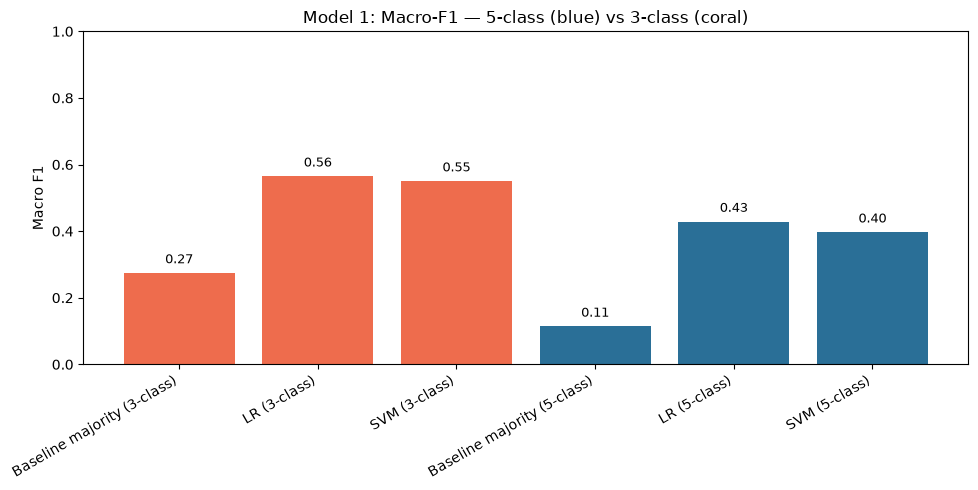

In [5]:
comparison_df = pd.DataFrame(results)[
    ['scheme', 'model', 'accuracy', 'macro_precision', 'macro_recall', 'macro_f1']
].sort_values(['scheme', 'model'])

print('MODEL 1 — 3-CLASS vs 5-CLASS COMPARISON')
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

comparison_df.to_csv('../data/processed/model1_3vs5_comparison.csv', index=False)

# Bar chart of macro-F1
plot_df = comparison_df.copy()
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df))
colors = ['#2a6f97' if s == '5-class' else '#ee6c4d' for s in plot_df['scheme']]
bars = ax.bar(x, plot_df['macro_f1'], color=colors)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['model'], rotation=30, ha='right')
ax.set_ylabel('Macro F1')
ax.set_title('Model 1: Macro-F1 — 5-class (blue) vs 3-class (coral)')
ax.set_ylim(0, 1)
for bar, val in zip(bars, plot_df['macro_f1']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../visuals/model1_3vs5_comparison.png', dpi=150)
plt.show()

### Confusion Matrices

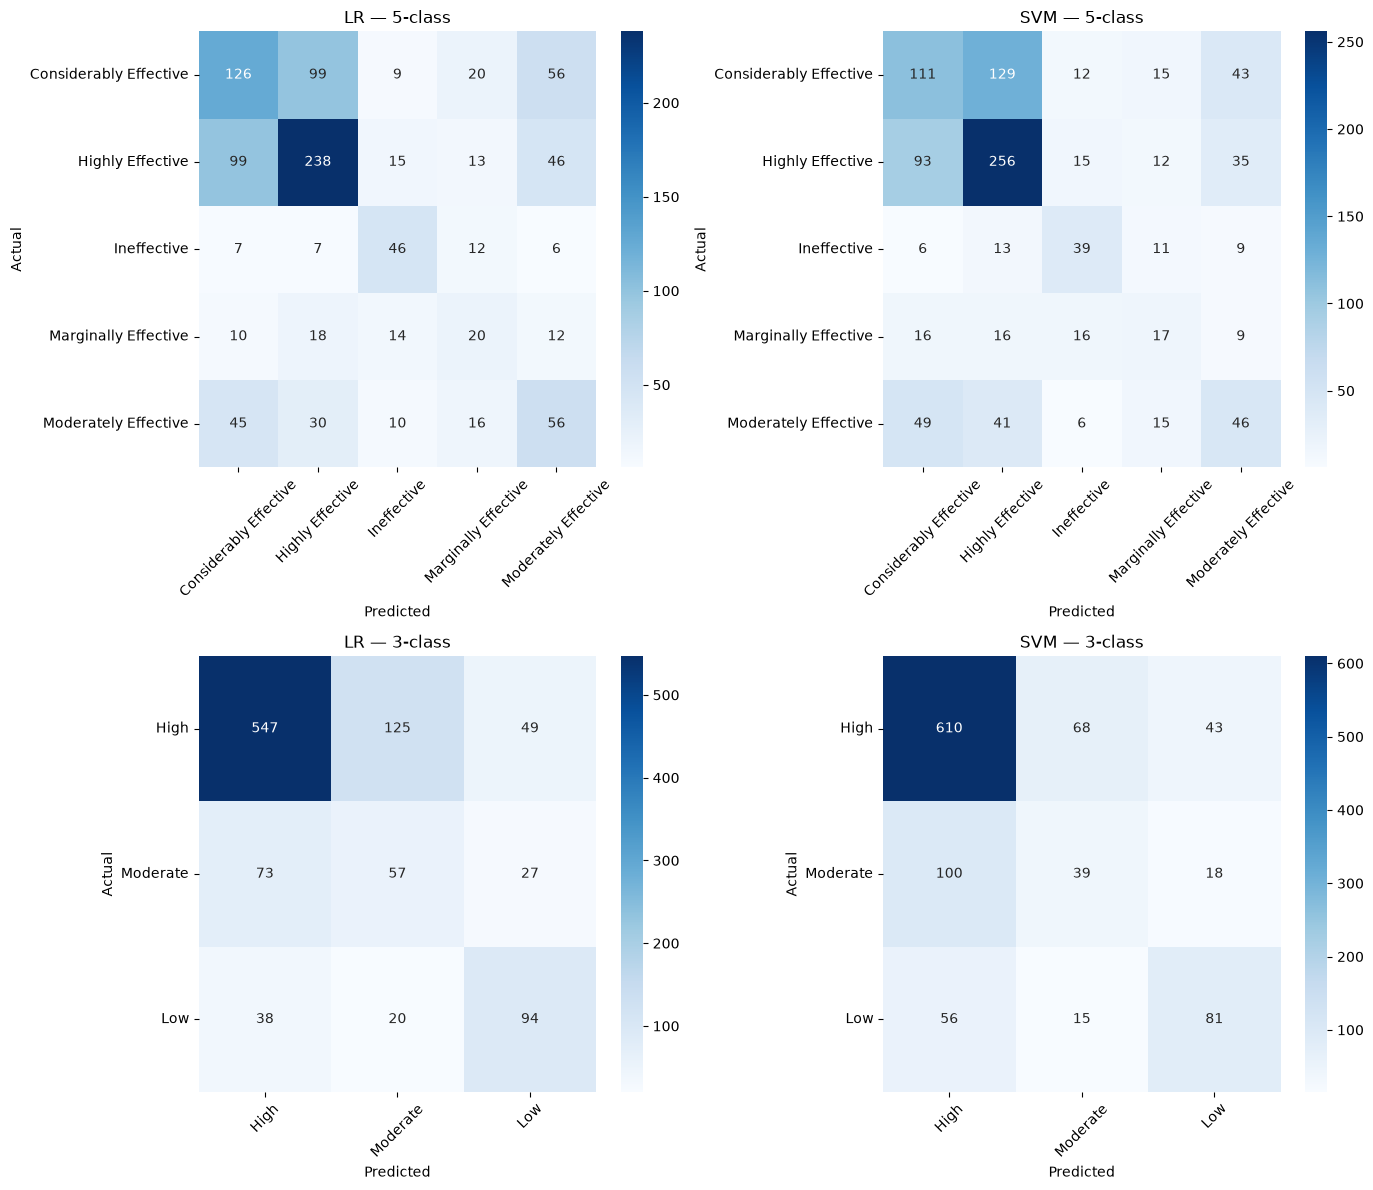

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

plot_confusion(axes[0, 0], y_test_5, y_pred_lr_5, 'LR — 5-class', labels_5)
plot_confusion(axes[0, 1], y_test_5, y_pred_svm_5, 'SVM — 5-class', labels_5)
plot_confusion(axes[1, 0], y_test_3, y_pred_lr_3, 'LR — 3-class', labels_3)
plot_confusion(axes[1, 1], y_test_3, y_pred_svm_3, 'SVM — 3-class', labels_3)

plt.tight_layout()
plt.savefig('../visuals/model1_confusion_matrices.png', dpi=150)
plt.show()

### Feature Importance — Top Words per Class (Logistic Regression)

In [7]:
feature_names = tfidf_vectorizer.get_feature_names_out()

def top_words_per_class(model, class_labels, top_n=10):
    coef = model.coef_
    # For multinomial LR, classes_ order matches coef rows
    for i, cls in enumerate(model.classes_):
        top_idx = np.argsort(coef[i])[-top_n:][::-1]
        words = [feature_names[j] for j in top_idx]
        print(f'\n{cls}:')
        print(', '.join(words))

print('=== 5-CLASS Logistic Regression — top words ===')
top_words_per_class(log_reg_5, labels_5)

print('\n=== 3-CLASS Logistic Regression — top words ===')
top_words_per_class(log_reg_3, labels_3)

=== 5-CLASS Logistic Regression — top words ===

Considerably Effective:
able, significantly, also, feeling, infection cleared, energy, considerably, reduce, eyelash, work well

Highly Effective:
within, year, pregnancy, life, almost, normal, immediate, extremely, completely, longer

Ineffective:
none, benefit, not, treat, antibiotic, nothing, whatsoever, not benefit, effect, amoxicillin

Marginally Effective:
improvement, slightly, benefit, not much, slight improvement, supposed, head, marginal, believe, far

Moderately Effective:
moderate, reduced, event, redness, moderately, helped, lessened, worse, though, wrinkle

=== 3-CLASS Logistic Regression — top words ===

High:
within, year, also, almost, pregnancy, feeling, able, life, greatly, eliminated

Low:
benefit, none, improvement, not, antibiotic, believe, slight, head, nothing, possible

Moderate:
moderate, event, reduced, moderately, redness, worse, without, treatment cleared, lisinopril, though


### Discussion — 3-class vs 5-class

- **5-class** preserves fine-grained labels useful for nuanced dashboards, but adjacent categories (e.g., Highly vs Considerably) are hard to separate from short benefits text, which depresses macro-F1.
- **3-class** (High / Moderate / Low) reduces label noise and typically lifts accuracy and macro-F1, at the cost of granularity.
- **Stakeholder fit:** pharmacovigilance triage may prefer 3-class (flag Low quickly); research UX surfaces may prefer 5-class with calibrated confidence.
- Both LR and SVM should beat the majority baseline; LR remains preferred when coefficient interpretability matters.

Artifacts saved: `visuals/model1_3vs5_comparison.png`, `visuals/model1_confusion_matrices.png`, `data/processed/model1_3vs5_comparison.csv`.

In [8]:
# Persist best models for Evaluation / Deployment notebooks
with open('../data/processed/model1_log_reg_5.pkl', 'wb') as f:
    pickle.dump(log_reg_5, f)
with open('../data/processed/model1_log_reg_3.pkl', 'wb') as f:
    pickle.dump(log_reg_3, f)
with open('../data/processed/model1_svm_5.pkl', 'wb') as f:
    pickle.dump(svm_5, f)
with open('../data/processed/model1_svm_3.pkl', 'wb') as f:
    pickle.dump(svm_3, f)

print('Saved Model 1 classifiers to data/processed/')
print('\nFinal comparison snapshot:')
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Saved Model 1 classifiers to data/processed/

Final comparison snapshot:
 scheme                       model  accuracy  macro_precision  macro_recall  macro_f1
3-class Baseline majority (3-class)    0.7000           0.2333        0.3333    0.2745
3-class                LR (3-class)    0.6777           0.5555        0.5800    0.5649
3-class               SVM (3-class)    0.7087           0.5621        0.5424    0.5503
5-class Baseline majority (5-class)    0.3990           0.0798        0.2000    0.1141
5-class                LR (5-class)    0.4718           0.4201        0.4404    0.4288
5-class               SVM (5-class)    0.4553           0.3953        0.4007    0.3969
